In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

RANDOM_STATE = 42

In [3]:
USERS_PATH = "takehome_users.csv"
ENG_PATH = "takehome_user_engagement.csv"

users = pd.read_csv(USERS_PATH, encoding="latin1")
eng = pd.read_csv(ENG_PATH, encoding="latin1")

print("users:", users.shape)
print("engagement:", eng.shape)

display(users.head())
display(eng.head())

users: (12000, 10)
engagement: (207917, 3)


,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0


,time_stamp,user_id,visited
0,2014-04-22 03:53:30,1,1
1,2013-11-15 03:45:04,2,1
2,2013-11-29 03:45:04,2,1
3,2013-12-09 03:45:04,2,1
4,2013-12-25 03:45:04,2,1


In [4]:
users["creation_time"] = pd.to_datetime(users["creation_time"], errors="coerce")
eng["time_stamp"] = pd.to_datetime(eng["time_stamp"], errors="coerce")

eng["date"] = eng["time_stamp"].dt.normalize()

users.isna().mean().sort_values(ascending=False).head(10)

invited_by_user_id            0.46525
last_session_creation_time    0.26475
object_id                     0.00000
creation_time                 0.00000
name                          0.00000
email                         0.00000
creation_source               0.00000
opted_in_to_mailing_list      0.00000
enabled_for_marketing_drip    0.00000
org_id                        0.00000
dtype: float64

In [5]:
def is_adopted(unique_dates: np.ndarray) -> bool:
    if len(unique_dates) < 3:
        return False

    i = 0
    for j in range(len(unique_dates)):
        while unique_dates[j] - unique_dates[i] > np.timedelta64(6, "D"):
            i += 1
        if (j - i + 1) >= 3:
            return True
    return False

dates_by_user = eng.groupby("user_id")["date"].apply(lambda s: np.sort(s.dropna().unique()))
adopted_flag = dates_by_user.apply(is_adopted)

users["adopted"] = users["object_id"].map(adopted_flag).fillna(False).astype(int)

adoption_rate = users["adopted"].mean()
print(f"Adoption rate: {adoption_rate:.3%} ({users['adopted'].sum()} / {len(users)})")
users["adopted"].value_counts()

Adoption rate: 13.350% (1602 / 12000)


C:\Users\Muhammad\AppData\Local\Temp\ipykernel_39532\2655666969.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  users["adopted"] = users["object_id"].map(adopted_flag).fillna(False).astype(int)


adopted
0    10398
1     1602
Name: count, dtype: int64

,rate,n
creation_source,,
SIGNUP_GOOGLE_AUTH,0.167509,1385
GUEST_INVITE,0.166436,2163
SIGNUP,0.140393,2087
ORG_INVITE,0.129995,4254
PERSONAL_PROJECTS,0.077688,2111


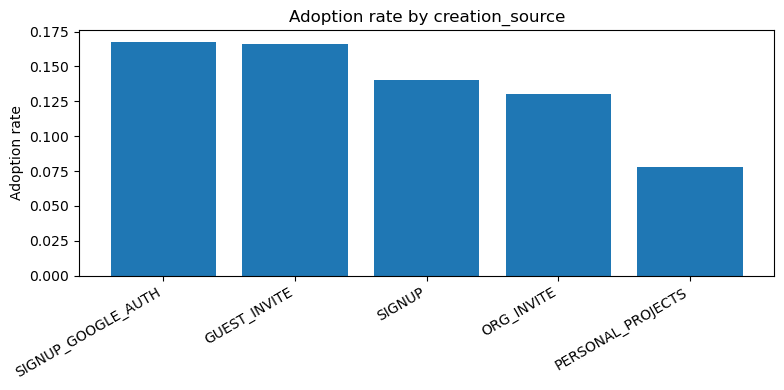

In [6]:
adopt_by_source = (
    users.groupby("creation_source")["adopted"]
    .agg(rate="mean", n="size")
    .sort_values("rate", ascending=False)
)

display(adopt_by_source)

plt.figure(figsize=(8,4))
plt.bar(adopt_by_source.index, adopt_by_source["rate"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Adoption rate")
plt.title("Adoption rate by creation_source")
plt.tight_layout()
plt.show()

In [7]:
df = users.copy()

df["creation_weekday"] = df["creation_time"].dt.weekday
df["creation_hour"] = df["creation_time"].dt.hour

df["invited"] = df["invited_by_user_id"].notna().astype(int)

df["email_domain"] = df["email"].astype(str).str.lower().str.split("@").str[-1]
top_domains = df["email_domain"].value_counts().head(10).index
df["email_domain_top"] = df["email_domain"].where(df["email_domain"].isin(top_domains), other="other")

org_counts = df["org_id"].value_counts()
df["org_size"] = df["org_id"].map(org_counts)

FEATURES = [
    "creation_source",
    "opted_in_to_mailing_list",
    "enabled_for_marketing_drip",
    "invited",
    "creation_weekday",
    "creation_hour",
    "email_domain_top",
    "org_size",
]

X = df[FEATURES]
y = df["adopted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

cat_features = ["creation_source", "email_domain_top", "creation_weekday", "creation_hour"]
num_features = ["opted_in_to_mailing_list", "enabled_for_marketing_drip", "invited", "org_size"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_features),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_features),
    ]
)

model = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])

model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['creation_source',
                                                   'email_domain_top',
                                                   'creation_weekday',
                                                   'creation_hour']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['opted_in_to_mailing_list',
                                                   'enabled_for_marketing_drip',
                                                   'invited', 'org_size'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [8]:
model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, proba)
ap = average_precision_score(y_test, proba)

print(f"ROC AUC: {roc_auc:.3f}")
print(f"Average precision (PR AUC): {ap:.3f}")
print()

print("Confusion matrix (threshold=0.5):")
print(confusion_matrix(y_test, pred))
print()

print(classification_report(y_test, pred, digits=3))

ROC AUC: 0.613
Average precision (PR AUC): 0.183

Confusion matrix (threshold=0.5):
[[1374 1226]
 [ 136  264]]

              precision    recall  f1-score   support

           0      0.910     0.528     0.669      2600
           1      0.177     0.660     0.279       400

    accuracy                          0.546      3000
   macro avg      0.544     0.594     0.474      3000
weighted avg      0.812     0.546     0.617      3000



In [9]:
import numpy as np
import pandas as pd

ohe = model.named_steps["preprocess"].named_transformers_["cat"].named_steps["ohe"]
cat_names = ohe.get_feature_names_out(cat_features)
feature_names = np.concatenate([cat_names, np.array(num_features)])

coefs = model.named_steps["clf"].coef_[0]
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["odds_ratio"] = np.exp(coef_df["coef"])

display(coef_df.sort_values("odds_ratio", ascending=False).head(15))
display(coef_df.sort_values("odds_ratio", ascending=True).head(15))

,feature,coef,odds_ratio
36,creation_hour_14,0.413455,1.512033
44,creation_hour_22,0.370564,1.448551
8,email_domain_top_hotmail.com,0.316554,1.372391
4,creation_source_SIGNUP_GOOGLE_AUTH,0.281563,1.325200
30,creation_hour_8,0.250635,1.284841
0,creation_source_GUEST_INVITE,0.215647,1.240665
37,creation_hour_15,0.187535,1.206272
3,creation_source_SIGNUP,0.167565,1.182422
28,creation_hour_6,0.162222,1.176121
48,invited,0.154742,1.167357


,feature,coef,odds_ratio
2,creation_source_PERSONAL_PROJECTS,-0.513323,0.598503
38,creation_hour_16,-0.304806,0.737266
40,creation_hour_18,-0.285296,0.751792
23,creation_hour_1,-0.262970,0.768765
31,creation_hour_9,-0.227780,0.796299
14,email_domain_top_yahoo.com,-0.184498,0.831522
45,creation_hour_23,-0.165162,0.847756
34,creation_hour_12,-0.153449,0.857745
43,creation_hour_21,-0.105030,0.900298
35,creation_hour_13,-0.103193,0.901953
